In [ ]:
import numpy as np
from gpcam import GPOptimizer

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import os

from sklearn.neighbors import NearestNeighbors

from scipy.spatial.distance import cdist

import time


import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Using Data Extracted from the Firedrake environment

In [ ]:
# Load the saved data
data = np.load('Data/dragon_complete_dataset_from_firedrake.npz')

# Extract all the data
vertices = data['vertices']                      # All mesh vertices (N, 3)
ground_truth = data['ground_truth']              # Ground truth values (N,)

del data 

# Running one GP model Training with Random points

In [ ]:
# Need to be computed before being able to be used.

# Loading the subset geodesic distance
matrix_size = 100179
geodesic_matrix = np.memmap('/dragon_geodesic_matrix_100179_new.npy',
                            dtype=np.float32,
                            mode='r',
                            shape=(matrix_size, matrix_size))


# Method 1: Direct conversion (simplest)
all_geodesic_distances = np.array(geodesic_matrix)

del geodesic_matrix


In [7]:
# Step 1: First sample the subset of points
np.random.seed(2355)

# Step 3: Now split the subset into train and test
n_train = 1000
n_test = 5000

# Sample ALL indices at once, then split
indices_all = np.random.choice(len(vertices), size=n_train + n_test, replace=False)

# Split into train and test
indices_train = indices_all[:n_train]
indices_test = indices_all[n_train:]

# Extract data
x_train = vertices[indices_train,:]
y_train = ground_truth[indices_train]

x_test = vertices[indices_test,:]
y_test = ground_truth[indices_test]

print(f"Training points: {len(indices_train)}")
print(f"Test points: {len(indices_test)}")

Training points: 1000
Test points: 5000


In [ ]:
# Step 2: Define the basic GP components

def matern_kernel_diff1(distance, length):
    kernel = (1.0 + ((np.sqrt(3.0) * distance) / length)) * np.exp(
        -(np.sqrt(3.0) * distance) / length
    )
    return kernel

    
def find_indices_by_lookup_efficient(target_points, all_points, tolerance=1e-10):     
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(all_points)
    distances, indices = nbrs.kneighbors(target_points)
    return indices.flatten()
    

def bump(d, r, beta, ampl):
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

def bump_k(x1, x2, hps):
    x1_indices = find_indices_by_lookup_efficient(x1, vertices)
    x2_indices = find_indices_by_lookup_efficient(x2, vertices)
    indices_train_comp = find_indices_by_lookup_efficient(x_train, vertices) 
    
    # Extract geodesic distances
    # d1: distances from x1 points to training points
    d1 = all_geodesic_distances[np.ix_(x1_indices, indices_train_comp)]  # Shape: (len(x1), n_train)
    d2 = all_geodesic_distances[np.ix_(x2_indices, indices_train_comp)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    phi_x1 = bump(d1, hps[1], beta=1, ampl=1.0)  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=1.0)  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    #return hps[0] * np.exp(-D_mat**2 / hps[2])
    return hps[0] * matern_kernel_diff1(D_mat, hps[2])

def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-5  # hps[3]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [ ]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
y_var = np.var(y_train)

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([0.01 * y_var, 10 * y_var])                             # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
bounds[2] = np.array([0.01, 100])                                            # length_scale for RBF on embeddings


# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)

# # Training hyperparameters (from previous run)
# trained_hps = np.array([20.94945291,  0.11843309, 44.54541338])

print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)

print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# # Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global')

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")


Initial hyperparameters: [10.49286108  0.16731294 50.005     ]
Initial log likelihood: -970.830404
Final hyperparameters:   [20.94945291  0.11843309 44.54541338]
Final log likelihood:    1660.76


RMSE: 0.0005676421768406346


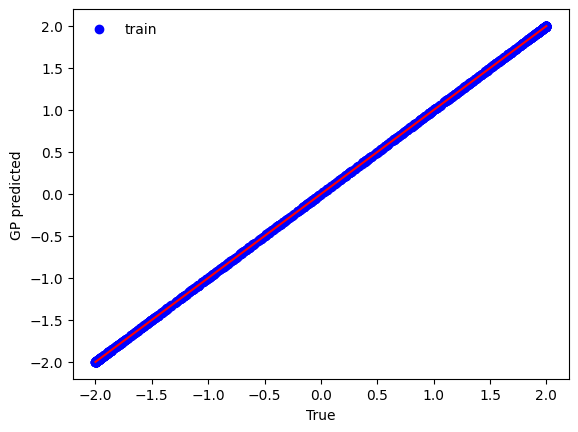

In [ ]:
# Train RMSE

f_train = my_gpo.posterior_mean(x_train)["m(x)"]
my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(x_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 0.03104973338943922


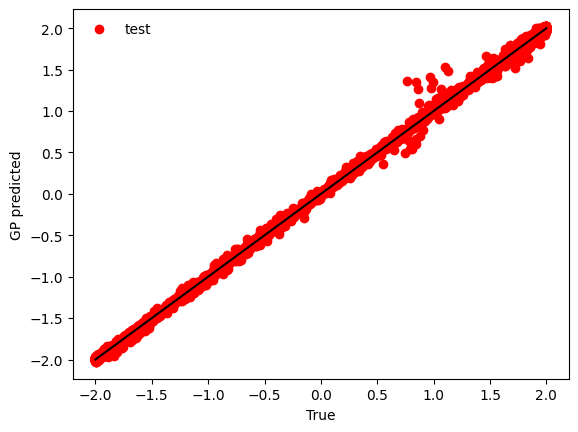

In [ ]:
# Test RMSE

f = my_gpo.posterior_mean(x_test)["m(x)"]

print('RMSE:', my_gpo.rmse(x_test,y_test)) # *100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [ ]:
# Predicting the output for all the vertices

x_test = vertices# [indices_test,:]
f = my_gpo.posterior_mean(x_test)["m(x)"]

In [ ]:
# Plotting the Dragon with with the predicted values for the test points and the training points in black

fig = go.Figure(data=[go.Scatter3d(
                            x=x_test[:,0],
                            y=x_test[:,1],
                            z=x_test[:,2], 
                            mode='markers', 
                            marker=dict(size=5, color=f, colorscale='plasma',opacity=0.8,
                                        #cmin= np.min(my_kernel_plot),
                                        #cmax= np.max(my_kernel_plot),
                                       showscale=True,  # This adds the colorbar
                                      colorbar=dict(thickness=15,
                                                    len=0.7)),
                            name="Test Points"  # Add name for legend
                        )])

# Add x_train data with black colors
fig.add_trace(go.Scatter3d(
    x=x_train[:, 0],
    y=x_train[:, 1],
    z=x_train[:, 2], 
    mode='markers',
    marker=dict(
        size=5,  # Same size as test points
        color='black',  # Black color
        opacity=0.8,
        line=dict(width=0.5, color='gray')  # Optional: add gray border
    ),
    name="Train Points"
))

# Highlight the first point
fig.add_trace(go.Scatter3d(
    x=[x_test[0, 0]],
    y=[x_test[0, 1]],
    z=[x_test[0, 2]], 
    mode='markers+text',
    marker=dict(
        size=15,  # Larger size
        color='red',  # Different color
        symbol='diamond',  # Different shape
        line=dict(width=3, color='white')  # White border
    ),
    text=["First Point"],
    textposition="top center",
    textfont=dict(size=14, color='white'),
    name="First Point"
))

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

# Running Several GP Trials with Different Training Sizes

In [ ]:
import numpy as np
import json
from tqdm import tqdm
from scipy.stats import norm

In [ ]:
def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = vertices[test_indices]
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = vertices[indices_train]
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(y_train,indices_train):

    # 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
    y_var = np.var(y_train)
    
    # 2. Bump radius (hps[1]): [min distance, maximum distance]
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    # Define hyperparameter bounds
    bounds = np.empty((3, 2))
    bounds[0] = np.array([0.01 * y_var, 10 * y_var])                             # sigma_f: signal variance      
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
    bounds[2] = np.array([0.01, 100])                                            # length_scale for RBF on embeddings
    
    return bounds

def train_gp_model(x_train, y_train, bounds):
    """Train GP model with existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='mcmc', 
                 max_iter=4000)
    
    return my_gpo

def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'dragon_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'dragon_results_SLE_Kernel.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, vertices, ground_truth)
    #print(f"Test data shape: {x_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        trials = configs['training_configurations'][str(train_size)]
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"Skipping trial {trial_idx} (already completed)")
                continue

            try:
                # Get training data for this trial
                x_train, y_train, seed, indices_train = get_training_data(configs, train_size, trial_idx, vertices, ground_truth)


                ##################
                # Make x_train global so kernel functions can access it
                globals()['x_train'] = x_train  
                globals()['y_train'] = y_train
                globals()['indices_train'] = indices_train  
                ##################
                
                # Identify the hps bounds
                bounds = get_hps_bounds(y_train,indices_train)

                # Train GP model
                my_gpo = train_gp_model(x_train, y_train, bounds)
                
                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)
                
                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)

                # Compute CRPS
                crps_test = my_gpo.crps(x_test, y_test)

                # Compute picp
                picp_test = picp(my_gpo, x_test, y_test)
                
                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                
                # Save after each trial
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"  Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} Saved")
                
            except Exception as e:
                print(f"Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("Starting GP experiments...")
print("="*60)

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"Completed! Total experiments: {len(results)}")